# Fine-Tuning StableDiffusion XL with DreamBooth

Over the past few years Generative AI models have popped up everywhere - from creating realistic responses to complex questions, to generating images and music to impress art critics around the globe. In this notebook we use the Hugging Face [Stable Diffusion XL (SDXL)](https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0) model to create images from text prompts. You'll see how to import the SDXL model and use it to generate an image. 

From there, you'll see how you can fine-tune the model using [DreamBooth](https://huggingface.co/docs/diffusers/training/dreambooth), a method for easily fine-tuning a text-to-image model. We'll use a small number of photos of [Toy Jensen](https://blogs.nvidia.com/blog/2022/12/22/toy-jensen-jingle-bells/) in this notebook to fine-tune SDXL. This will allow us to generate new images that include Toy Jensen! 

After that, you'll have the chance to fine-tune the model on your own images. Perhaps you want to create an image of you at the bottom of the ocean, or in outer space? By the end of this notebook you will be able to! 

**IMPORTANT:** This project will utilize additional third-party open source software. Review the license terms of these open source projects before use. Third party components used as part of this project are subject to their separate legal notices or terms that accompany the components. You are responsible for confirming compliance with third-party component license terms and requirements.

### Stable Diffusion XL Model

First, we import the classes and libraries we need to run the notebook.

In [ ]:
import torch
from diffusers import StableDiffusionXLPipeline, DiffusionPipeline
print("torch:", torch.__version__)
print("cuda runtime:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu0:", torch.cuda.get_device_name(0))
    print("gpu1:", torch.cuda.get_device_name(1))

In [ ]:
from diffusers import StableDiffusionXLPipeline, DiffusionPipeline
print("diffusers import ok")

Next, from the Hugging Face `diffusers` library, we create a `StableDiffusionXLPipeline` object from the SDXL base model. 

In [ ]:
pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, variant="fp16", use_safetensors=True
)
pipe.to("cuda")

Let's use the SDXL model to generate an image. 

In [ ]:
prompt = "Muren Person Women on Beach"
image = pipe(prompt=prompt).images[0]

image

Hmmm, looks like the Hugging Face SDXL model doesn't know about Toy Jensen! Imagine that! 

✅ Try using the SDXL model to generate some other images by editing the text in the first line of the cell above. 


## Fine-Tuning the model with DreamBooth

Fine-Tuning is used to train an existing Machine Learning Model, given new information. In our case, we want to teach the SDXL model about Toy Jensen. This will allow us to create the perfect image of Toy Jensen in Space!

[DreamBooth](https://arxiv.org/abs/2208.12242) provides a way to fine-tune a text-to-image model using only a few images. Let's use this to tune our SDXL Model so that it knows about Toy Jensen!

We have 8 photos of Toy Jensen in our dataset - let's take a look at one of them.

In [ ]:
from IPython.display import Image

display(Image(filename='../data/my-data/IMG_9378.jpeg'))

Now we can use Hugging Face and DreamBooth to fine-tune this model. To do this we create a config, then specify some flags like an instance prompt, a resolution and a number of training steps for the fine-tuning algorithm to run. 

In [ ]:
!rm /project/data/my-data/.gitkeep

!ls /project/data/my-data


In [ ]:
from accelerate.utils import write_basic_config
write_basic_config()

In [ ]:
import os
import json

captions = {
    # Batch 1
    "IMG_2527.JPEG": "murenperson, petite asian woman, long black hair, sharp cheekbones, small nose, natural lips, red dress, sitting at bar, low light, indoor nightlife, realistic photo",
    "IMG_2534.PNG": "murenperson, petite asian woman, long black hair, sharp cheekbones, smiling, red dress, bar background, indoor lighting, realistic photo",
    "IMG_2594.JPEG": "murenperson, petite asian woman, long black hair, side profile, shooting range, holding rifle, white jeans, slim petite body, full body, realistic photo",
    "IMG_2603.JPEG": "murenperson, petite asian woman, long black hair, shooting range, holding pistol, white jeans, slim petite body, full body, realistic photo",
    "IMG_2701.JPEG": "murenperson, petite asian woman, long black hair, mirror selfie, standing, slim petite body, natural lighting, realistic photo",
    "IMG_2702.JPEG": "murenperson, petite asian woman, long black hair, side profile, mirror selfie, slim petite body, realistic photo",
    "IMG_2904.JPEG": "murenperson, petite asian woman, sleeping, natural face, no makeup, indoor lighting, realistic photo",
    "IMG_2985.JPEG": "murenperson, petite asian woman, sitting on bed, casual clothing, hair tied up, natural lighting, realistic photo",
    "63106443510__C9FDA982-9230-4A1A-B54B-8224E943147B.JPEG": "murenperson, petite asian woman, sitting in bathtub, long black hair, slim petite body, bathroom lighting, realistic photo",
    "IMG_2444.JPEG": "murenperson, petite asian woman, lying on beach, bikini, slim petite body, outdoor sunlight, realistic photo",

    # Batch 2
    "IMG_3437.JPEG": "murenperson, petite asian woman, long black hair, crawling on floor, black dress, pink shoes, indoor apartment, hardwood floor, slim petite body, realistic photo",
    "IMG_3161.JPEG": "murenperson, petite asian woman, kneeling on bed, red shirt, gray leggings, bedroom, casual home setting, slim petite body, realistic photo",
    "IMG_3207.JPEG": "murenperson, petite asian woman, bikini, kneeling on beach, sunglasses, holding dog, ocean background, outdoor sunlight, slim petite body, realistic photo",
    "IMG_3233.JPEG": "murenperson, petite asian woman, standing on beach, green bikini, sunglasses, ocean waves, full body, outdoor sunlight, slim petite body, realistic photo",
    "IMG_3251.JPEG": "murenperson, petite asian woman, side profile, beach, long black hair, casual beach shirt, bikini bottom, ocean background, slim petite body, realistic photo",
    "IMG_3257.JPEG": "murenperson, petite asian woman, side profile close up, beach, long black hair, casual beach shirt, bikini bottom, outdoor sunlight, slim petite body, realistic photo",
    "IMG_3293.JPEG": "murenperson, petite asian woman, standing on boat, green bikini, holding drink can, ocean background, outdoor sunlight, slim petite body, realistic photo",
    "IMG_3294.JPEG": "murenperson, petite asian woman, standing on boat, green bikini, holding drink, ocean background, smiling, outdoor sunlight, slim petite body, realistic photo",
    "IMG_3297.JPEG": "murenperson, petite asian woman, side body close up, green bikini, on boat, ocean background, slim petite body, outdoor sunlight, realistic photo",
    "IMG_3313.JPEG": "murenperson, petite asian woman, holding fish, sitting on boat, fishing, ocean background, casual fishing outfit, slim petite body, realistic photo",

    # Batch 3
    "IMG_4289.JPEG": "murenperson, petite asian woman, sitting on balcony, smoking blunt, white t shirt, black underwear, ocean view, natural sunlight, slim petite body, realistic photo",
    "IMG_3651.JPEG": "murenperson, petite asian woman, lying on bed, pink thong, bedroom, indoor lighting, slim petite body, realistic photo",
    "IMG_3765.JPEG": "murenperson, petite asian woman, limousine interior, black top, white jeans, nightlife, sitting next to friend, low light, realistic photo",
    "IMG_3774.JPEG": "murenperson, petite asian woman, limousine interior, black top, white jeans, nightlife, sitting pose, low light, realistic photo",
    "IMG_3786.JPEG": "murenperson, petite asian woman, limousine interior, standing, white jeans, black top, nightlife, low light, slim petite body, realistic photo",
    "IMG_3795.JPEG": "murenperson, petite asian woman, selfie with man, limousine interior, nightlife, low light, realistic photo",
    "IMG_3804.JPEG": "murenperson, petite asian woman, selfie with man, limousine interior, nightlife, low light, realistic photo",
    "IMG_3823.JPEG": "murenperson, petite asian woman, selfie with man, sticking tongue out, limousine interior, nightlife, realistic photo",
    "IMG_4287.JPEG": "murenperson, petite asian woman, sitting on balcony, smoking blunt, white t shirt, black underwear, ocean view, natural sunlight, realistic photo",
    "IMG_4288.JPEG": "murenperson, petite asian woman, sitting on balcony, smoking blunt, white t shirt, black underwear, ocean view, natural sunlight, realistic photo",

    # Batch 4
    "IMG_4381.JPEG": "murenperson, petite asian woman, white bikini, beach walkway, sun hat, holding vape, outdoor sunlight, slim petite body, realistic photo",
    "IMG_4328.JPEG": "murenperson, petite asian woman, white bikini, balcony, ocean view, sitting on chair, smoking blunt, natural sunlight, realistic photo",
    "IMG_4329.JPEG": "murenperson, petite asian woman, white bikini, balcony, ocean view, sitting cross legged, smoking blunt, natural sunlight, realistic photo",
    "IMG_4330.JPEG": "murenperson, petite asian woman, white bikini, balcony, ocean view, sitting cross legged, smoking blunt, natural sunlight, realistic photo",
    "IMG_4365.JPEG": "murenperson, petite asian woman, white bikini, sitting with man, outdoor patio, sun hat, natural sunlight, realistic photo",
    "IMG_4366.JPEG": "murenperson, petite asian woman, white bikini, sitting with man, outdoor patio, sun hat, natural sunlight, realistic photo",
    "IMG_4367.JPEG": "murenperson, petite asian woman, white bikini, sitting with man, outdoor patio, sun hat, natural sunlight, realistic photo",
    "IMG_4372.JPEG": "murenperson, petite asian woman, white bikini, sitting on beach with man, dog nearby, outdoor sunlight, slim petite body, realistic photo",
    "IMG_4379.JPEG": "murenperson, petite asian woman, white bikini, walking on beach street, sun hat, holding vape, outdoor sunlight, slim petite body, realistic photo",
    "IMG_4380.JPEG": "murenperson, petite asian woman, white bikini, walking toward camera, beach street, sun hat, outdoor sunlight, slim petite body, realistic photo",

    # Batch 5
    "IMG_4386.JPEG": "murenperson woman, petite asian woman, long dark hair, sunglasses, white bikini top, holding drinks, sitting on beach towel, beach, sunny daylight, candid photo",
    "IMG_4387.JPEG": "murenperson woman, petite asian woman, long dark hair, sunglasses, white bikini top, talking expression, sitting on beach towel, beach, sunny daylight, candid photo",
    "IMG_4388.JPEG": "murenperson woman, petite asian woman, long dark hair, sunglasses, white bikini top, leaning back, relaxed pose, beach, sunny daylight, candid photo",
    "IMG_4389.JPEG": "murenperson woman, petite asian woman, long dark hair, sunglasses, white bikini top, sitting at beach picnic, ocean background, sunny daylight, candid photo",
    "IMG_4391.JPEG": "murenperson woman, petite asian woman, long dark hair, sunglasses, white bikini top, hand near mouth, sitting on beach towel, beach, sunny daylight, candid photo",
    "IMG_4392.JPEG": "murenperson woman, petite asian woman, long dark hair, sunglasses, white bikini top, beach picnic, sitting on towel, ocean background, sunny daylight, candid photo",
    "IMG_4395.JPEG": "murenperson woman, petite asian woman, long dark hair, sunglasses, white bikini top, holding oyster, beach picnic, sunny daylight, candid photo",
    "IMG_4396.JPEG": "murenperson woman, petite asian woman, long dark hair, sunglasses, white bikini top, eating oyster, beach, sunny daylight, candid photo",
    "IMG_4397.JPEG": "murenperson woman, petite asian woman, long dark hair, sunglasses, white bikini top, eating oyster, close portrait, beach, sunny daylight, candid photo",
    "IMG_4398.JPEG": "murenperson woman, petite asian woman, long dark hair, sunglasses, white bikini top, eating food, beach picnic, sunny daylight, candid photo",

    # Batch 6
    "IMG_4399.JPEG": "murenperson woman, petite asian woman, long dark hair, white bikini, lying on bed, side pose, indoor natural lighting, candid photo",
    "IMG_4400.JPEG": "murenperson woman, petite asian woman, long dark hair, sunglasses, white bikini, eating oyster, beach, sunny daylight, candid photo",
    "IMG_4402.JPEG": "murenperson woman, petite asian woman, long dark hair, sunglasses, white bikini, eating food, beach picnic, sunny daylight, candid photo",
    "IMG_4403.JPEG": "murenperson woman, petite asian woman, long dark hair, sunglasses, white bikini, adjusting sunglasses, beach, sunny daylight, candid photo",
    "IMG_4404.JPEG": "murenperson woman, petite asian woman, long dark hair, sunglasses, white bikini, adjusting hair, beach, sunny daylight, candid photo",
    "IMG_4405.JPEG": "murenperson woman, petite asian woman, long dark hair, sunglasses, white bikini, hands near face, beach, sunny daylight, candid photo",
    "IMG_4406.JPEG": "murenperson woman, petite asian woman, long dark hair, sunglasses, white bikini, sitting at beach table, drink in foreground, sunny daylight, candid photo",
    "IMG_4408.JPEG": "murenperson woman, petite asian woman, long dark hair, sunglasses, white bikini, leaning forward, beach, sunny daylight, candid photo",
    "IMG_4437.JPEG": "murenperson woman, petite asian woman, long dark hair, white bikini, back pose, sitting on beach towel, ocean background, sunny daylight, candid photo",
    "IMG_4442.JPEG": "murenperson woman, petite asian woman, long dark hair, white bikini, lying on bed, back pose, indoor natural lighting, candid photo",

    # Batch 7
    "IMG_5268.JPEG": "murenperson, petite asian woman, long black hair, sharp cheekbones, small nose, natural lips, smiling, standing pose, wearing plaid bikini and clear heels, slim petite body, hands visible, natural hand position, indoor hallway, warm indoor lighting, realistic photo",
    "IMG_5269.JPEG": "murenperson, petite asian woman, long black hair, sharp cheekbones, playful expression, eyes closed, holding middle fingers up, hands visible, natural hand position, wearing plaid bikini and clear heels, slim petite body, indoor hallway, warm indoor lighting, realistic photo",
    "IMG_5270.JPEG": "murenperson, petite asian woman, long black hair, hand covering face, partial face occlusion, hands visible, natural hand position, wearing plaid bikini and clear heels, slim petite body, standing pose, indoor hallway, warm indoor lighting, realistic photo",
    "IMG_5376.JPEG": "murenperson, petite asian woman, long black hair, smiling, walking forward, arms slightly raised, hands visible, natural hand position, wearing patterned bikini, slim petite body, outdoor walkway at night, city lights, night lighting, realistic photo",
    "IMG_5378.JPEG": "murenperson, petite asian woman, long black hair, smiling, standing pose, looking to the side, hands visible, natural hand position, wearing patterned bikini and heels, slim petite body, outdoor walkway at night, city skyline background, night lighting, realistic photo",
    "IMG_4514.JPEG": "murenperson, petite asian woman, long black hair, wearing sunglasses, eyes covered, relaxed expression, lying on beach chair, wearing green bikini, slim petite body, outdoor beach setting, bright sunlight, realistic photo",
    "IMG_5198.JPEG": "murenperson, petite asian woman, long black hair, natural face, closed mouth, relaxed expression, selfie, lying on couch, casual t-shirt, indoor lighting, realistic photo",
    "IMG_5200.JPEG": "murenperson, petite asian woman, long black hair, natural face, closed mouth, slight smile, selfie, lying on couch, small dog nearby, casual t-shirt, indoor lighting, realistic photo",
    "IMG_5201.JPEG": "murenperson, petite asian woman, long black hair, smiling, teeth visible, natural expression, selfie, lying on couch, small dog nearby, casual t-shirt, indoor lighting, realistic photo",
    "IMG_5213.JPEG": "murenperson, petite asian woman, long black hair, smiling, standing next to man, hand resting on chest, hands visible, natural hand position, birthday cake with candles, indoor home setting, warm indoor lighting, realistic photo",

    # Batch 8
    "IMG_5391.JPEG": "murenperson, petite asian woman, long black hair, sharp cheekbones, small nose, natural lips, smiling, standing in bushes, partial body occlusion, hands visible, natural hand position, wearing patterned bikini, slim petite body, outdoor garden at night, warm building lights, realistic photo",
    "IMG_5379.JPEG": "murenperson, petite asian woman, long black hair, smiling, walking forward, arms raised near head, hands visible, natural hand position, wearing patterned bikini and clear heels, slim petite body, outdoor walkway at night, city skyline, night lighting, realistic photo",
    "IMG_5380.JPEG": "murenperson, petite asian woman, long black hair, smiling, standing pose, one hand raised, one hand on hip, hands visible, natural hand position, wearing patterned bikini and clear heels, slim petite body, outdoor walkway at night, city skyline, night lighting, realistic photo",
    "IMG_5381.JPEG": "murenperson, petite asian woman, long black hair, relaxed expression, eyes closed, touching face, partial face occlusion, hands visible, natural hand position, wearing patterned bikini and clear heels, slim petite body, outdoor walkway at night, city skyline, night lighting, realistic photo",
    "IMG_5383.JPEG": "murenperson, petite asian woman, long black hair, looking back over shoulder, smiling, back turned pose, hands visible, natural hand position, wearing patterned bikini and clear heels, slim petite body, outdoor walkway at night, city skyline, night lighting, realistic photo",
    "IMG_5384.JPEG": "murenperson, petite asian woman, long black hair, back view, walking away, hair flowing down back, hands visible, natural hand position, wearing patterned bikini and clear heels, slim petite body, outdoor walkway at night, city skyline, night lighting, realistic photo",
    "IMG_5387.JPEG": "murenperson, petite asian woman, long black hair, crouching in bushes, hand near face, partial face occlusion, hands visible, natural hand position, wearing patterned bikini, slim petite body, outdoor garden at night, warm building lights, realistic photo",
    "IMG_5388.JPEG": "murenperson, petite asian woman, long black hair, smiling, standing in bushes, turned body, hands visible, natural hand position, wearing patterned bikini, slim petite body, outdoor garden at night, warm building lights, realistic photo",
    "IMG_5389.JPEG": "murenperson, petite asian woman, long black hair, smiling, crouching pose, hands raised near chest, hands visible, natural hand position, wearing patterned bikini, slim petite body, outdoor garden at night, warm building lights, realistic photo",
    "IMG_5390.JPEG": "murenperson, petite asian woman, long black hair, neutral expression, standing pose, hands near waist, hands visible, natural hand position, wearing patterned bikini, slim petite body, partially in bushes, outdoor garden at night, warm building lights, realistic photo",

    # Batch 9
    "IMG_9060.JPEG": "murenperson, petite asian woman, long black hair, smiling with open mouth, expressive face, hands raised near collarbone, hands visible, natural hand position, wearing black dress, seated at restaurant table, dessert plate in front, warm ambient lighting, indoor dining setting, realistic photo",
    "IMG_5394.JPEG": "murenperson, petite asian woman, long black hair, relaxed expression, lying on couch, hand touching hair, partial face occlusion, hands visible, natural hand position, wearing patterned bikini top and loose pants, small brown dog lying next to her, indoor living room, warm lighting, realistic photo",
    "IMG_5395.JPEG": "murenperson, petite asian woman, long black hair, eyes closed, slight smile, lying on couch, stretching arms behind head, hands visible, natural hand position, wearing patterned bikini top and loose pants, small brown dog beside her, indoor living room, warm lighting, realistic photo",
    "IMG_5396.JPEG": "murenperson, petite asian woman, long black hair, eyes closed, resting pose, lying on couch, one arm extended forward, hands visible, natural hand position, wearing patterned bikini top and loose pants, small brown dog lying nearby, indoor living room, warm lighting, realistic photo",
    "IMG_5401.JPEG": "murenperson, petite asian woman, long black hair, sleeping pose, lying on couch facing dog, eyes closed, relaxed body, hands visible, natural hand position, wearing patterned bikini top and loose pants, small brown dog resting next to her, indoor living room, warm lighting, realistic photo",
    "IMG_5402.JPEG": "murenperson, petite asian woman, long black hair, sleeping pose, lying on couch, head resting near dog, eyes closed, hands visible, natural hand position, wearing patterned bikini top and loose pants, small brown dog in foreground, indoor living room, warm lighting, realistic photo",
    "IMG_6723.JPEG": "murenperson, petite asian woman, long black hair, smiling, sitting on arcade motorcycle game, one hand raised mid motion, hands visible, natural hand position, wearing black top, patterned skirt, and heels, indoor arcade, colorful neon lighting, realistic photo",
    "IMG_8468.JPEG": "murenperson, petite asian woman, long black hair tied back, wearing sunglasses, neutral expression, holding shaved ice dessert, hands visible, natural hand position, wearing grey dress, outdoor tropical setting, bright daylight, food stand background, realistic photo",
    "IMG_8470.JPEG": "murenperson, petite asian woman, long black hair tied back, wearing sunglasses, focused expression, eating shaved ice with spoon, hands visible, natural hand position, wearing grey dress, outdoor tropical setting, bright daylight, food stand background, realistic photo",
    "IMG_8905.JPEG": "murenperson, petite asian woman, long black hair, looking to side, face partially turned away, hands visible, natural hand position, wearing white top and underwear, indoor dressing room, mirror lighting, soft warm light, standing pose, realistic photo",

    # Batch 10
    "IMG_9072.JPEG": "murenperson, petite asian woman, long black hair, looking down smiling softly, relaxed expression, hands raised near chest, hands visible, natural hand position, wearing black dress, seated at restaurant table, dessert plate with candle in front, warm ambient lighting, indoor dining, realistic photo",
    "IMG_9061.JPEG": "murenperson, petite asian woman, long black hair, smiling with open mouth, looking to side, expressive face, hands mid motion near chest, hands visible, natural hand position, wearing black dress, seated at restaurant table, dessert plate with candle, warm ambient lighting, indoor dining, realistic photo",
    "IMG_9062.JPEG": "murenperson, petite asian woman, long black hair, neutral thoughtful expression, looking slightly upward to side, hands lowered out of frame, wearing black dress, seated at restaurant table, dessert plate visible, warm ambient lighting, indoor dining, realistic photo",
    "IMG_9063.JPEG": "murenperson, petite asian woman, long black hair, calm expression, looking to side, relaxed posture, one hand near lap partially visible, wearing black dress, seated at restaurant table, dessert plate visible, warm ambient lighting, indoor dining, realistic photo",
    "IMG_9064.JPEG": "murenperson, petite asian woman, long black hair, neutral expression, looking slightly upward, relaxed shoulders, hands out of frame, wearing black dress, seated at restaurant table, dessert plate visible, warm ambient lighting, indoor dining, realistic photo",
    "IMG_9065.JPEG": "murenperson, petite asian woman, long black hair, looking down at dessert, soft smile, focused gaze, hands out of frame, wearing black dress, seated at restaurant table, dessert plate with candle, warm ambient lighting, indoor dining, realistic photo",
    "IMG_9068.JPEG": "murenperson, petite asian woman, long black hair, slight smile, looking toward camera, hands mid motion near chest, hands visible, natural hand position, wearing black dress, seated at restaurant table, dessert plate with candle, warm ambient lighting, indoor dining, realistic photo",
    "IMG_9069.JPEG": "murenperson, petite asian woman, long black hair, smiling, direct gaze toward camera, hands raised under chin pose, hands visible, natural hand position, wearing black dress, seated at restaurant table, dessert plate with candle, warm ambient lighting, indoor dining, realistic photo",
    "IMG_9070.JPEG": "murenperson, petite asian woman, long black hair, playful expression, tongue slightly out, looking down, hands near chest, hands visible, natural hand position, wearing black dress, seated at restaurant table, dessert plate with candle, warm ambient lighting, indoor dining, realistic photo",
    "IMG_9071.JPEG": "murenperson, petite asian woman, long black hair, playful smile, looking downward, hands mid motion near chest, hands visible, natural hand position, wearing black dress, seated at restaurant table, dessert plate with candle, warm ambient lighting, indoor dining, realistic photo",

    # Batch 11
    "IMG_9074.JPEG": "murenperson, petite asian woman, long black hair, laughing with eyes closed, wide smile, one hand resting on chest, hands visible, natural hand position, wearing black dress, seated at restaurant table, dessert plate with candle in front, warm ambient lighting, indoor dining, realistic photo",
    "IMG_9075.JPEG": "murenperson, petite asian woman, long black hair, laughing, head turned to side, wide smile, one hand resting on chest, hands visible, natural hand position, wearing black dress, seated at restaurant table, dessert plate with candle in front, warm ambient lighting, indoor dining, realistic photo",
    "IMG_9076.JPEG": "murenperson, petite asian woman, long black hair, smiling, looking to side, one hand moving downward, hands visible, natural hand position, wearing black dress, seated at restaurant table, dessert plate with candle in front, warm ambient lighting, indoor dining, realistic photo",
    "IMG_9077.JPEG": "murenperson, petite asian woman, long black hair, laughing, head turned to side, expressive face, hands lowered near lap, wearing black dress, seated at restaurant table, dessert plate with candle in front, warm ambient lighting, indoor dining, realistic photo",
    "IMG_9078.JPEG": "murenperson, petite asian woman, long black hair, pursed lips, looking down at dessert, relaxed expression, hands lowered near lap, wearing black dress, seated at restaurant table, dessert plate with candle in front, warm ambient lighting, indoor dining, realistic photo",
    "IMG_9079.JPEG": "murenperson, petite asian woman, long black hair, playful expression, tongue slightly out, looking toward camera, hands mid motion near chest, hands visible, natural hand position, wearing black dress, seated at restaurant table, dessert plate with candle in front, warm ambient lighting, indoor dining, realistic photo",
    "IMG_9080.JPEG": "murenperson, petite asian woman, long black hair, smiling softly, head tilted, hands resting on chest, hands visible, natural hand position, wearing black dress, seated at restaurant table, dessert plate with candle in front, warm ambient lighting, indoor dining, realistic photo",
    "IMG_9081.JPEG": "murenperson, petite asian woman, long black hair, gentle smile, direct gaze toward camera, hands crossed on chest, hands visible, natural hand position, wearing black dress, seated at restaurant table, dessert plate with candle in front, warm ambient lighting, indoor dining, realistic photo",
    "IMG_9082.JPEG": "murenperson, petite asian woman, long black hair, looking down smiling softly, head tilted, hands resting on chest, hands visible, natural hand position, wearing black dress, seated at restaurant table, dessert plate with candle in front, warm ambient lighting, indoor dining, realistic photo",
    "IMG_9083.JPEG": "murenperson, petite asian woman, long black hair, soft smile, looking downward, hands spread across chest, hands visible, natural hand position, wearing black dress, seated at restaurant table, dessert plate with candle in front, warm ambient lighting, indoor dining, realistic photo",

    # Batch 12
    "IMG_9672.JPEG": "murenperson, petite asian woman, long black hair, standing in fitting room, looking over shoulder toward mirror reflection, slight smile, one hand adjusting skirt at waist, hands visible, natural hand position, wearing pink patterned blouse and black tweed skirt, barefoot, indoor retail fitting room, warm lighting, realistic photo",
    "IMG_9086.JPEG": "murenperson, petite asian woman, long black hair, smiling softly, both hands resting across chest, hands visible, natural hand position, wearing black dress, seated at restaurant table, dessert plate with candle in front, warm ambient lighting, indoor dining, realistic photo",
    "IMG_9087.JPEG": "murenperson, petite asian woman, long black hair, eyes closed, relaxed expression, hands raised near shoulders, hands visible, natural hand position, wearing black dress, seated at restaurant table, dessert plate with candle in front, warm ambient lighting, indoor dining, realistic photo",
    "IMG_9378.jpeg": "murenperson, petite asian woman, long black hair, studio pose, direct gaze at camera, neutral expression, one hand touching hair, one hand near shoulder, hands visible, natural hand position, wearing lavender lace lingerie set, standing against plain white background, professional lighting, realistic photo",
    "IMG_9670.JPEG": "murenperson, petite asian woman, long black hair, standing in fitting room, neutral expression, both hands adjusting waistband of skirt, hands visible, natural hand position, wearing pink patterned blouse and black tweed skirt, barefoot, indoor retail fitting room, mirror reflections visible, warm lighting, realistic photo",}

dataset_path = "/project/data/my-data"
metadata_path = os.path.join(dataset_path, "metadata.jsonl")

os.makedirs(dataset_path, exist_ok=True)

with open(metadata_path, "w", encoding="utf-8") as f:
    for file_name, prompt in captions.items():
        row = {"file_name": file_name, "prompt": prompt}
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

print(f"Created: {metadata_path}")
print(f"Rows written: {len(captions)}")

In [ ]:
pip install datasets

In [ ]:
!accelerate launch /workspace/diffusers/examples/dreambooth/train_dreambooth_lora_sdxl.py \
  --pretrained_model_name_or_path=stabilityai/stable-diffusion-xl-base-1.0 \
  --dataset_name="/project/data/my-data" \
  --image_column="image" \
  --caption_column="prompt" \
  --output_dir="/project/models/muren-sdxl" \
  --instance_prompt="a photo of murenperson woman" \
  --resolution=768 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=2000 \
  --mixed_precision="fp16" \
  --gradient_checkpointing \
  --checkpointing_steps=200 \
  --seed="0"

Now that the model is fine-tuned, let's tell our notebook where to find it.

In [ ]:
import gc
import torch
from diffusers import DiffusionPipeline

In [ ]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

In [ ]:
import torch
from diffusers import DiffusionPipeline

base_model_id = "stabilityai/stable-diffusion-xl-base-1.0"

pipe = DiffusionPipeline.from_pretrained(
    base_model_id,
    torch_dtype=torch.float16,
    use_safetensors=True,
)

pipe.load_lora_weights("/project/models/muren-sdxl/checkpoint-1400")

pipe.enable_attention_slicing()
pipe.vae.enable_slicing()
pipe.enable_model_cpu_offload()

In [ ]:
import os

output_dir = "/project/outputs"
os.makedirs(output_dir, exist_ok=True)

print("Created:", output_dir)
print("Exists:", os.path.exists(output_dir))

Finally, we can use our fine-tuned model to create an image with Toy Jensen in it. Let's give it a go! 

In [ ]:
import torch
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print("GPU cache cleared")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
Token indices sequence length is longer than the specified maximum sequence length for this model (81 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up

  0%|          | 0/35 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['lighting, realistic photo']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['lighting, realistic photo']


Saved: /project/outputs/beach_backside/muren_backside_seed_1907369810.png


...

  0%|          | 0/35 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['lighting, realistic photo']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['lighting, realistic photo']


Saved: /project/outputs/beach_backside/muren_backside_seed_501596464.png


  0%|          | 0/35 [00:00<?, ?it/s]

Saved: /project/outputs/beach_backside/muren_backside_seed_358685438.png


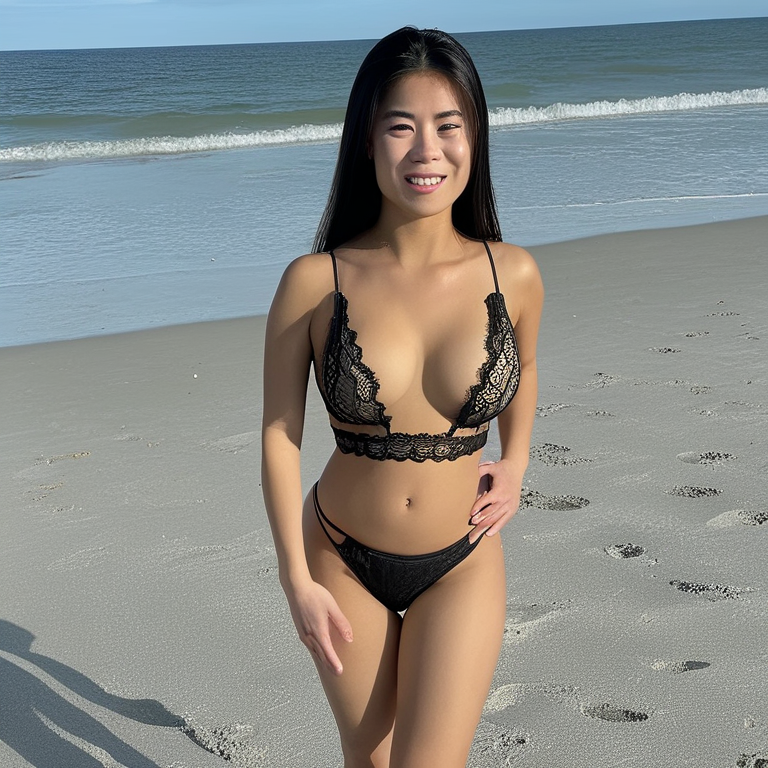

In [1]:
import os
import torch
import random
from diffusers import DiffusionPipeline

# -----------------------------
# LOAD PIPELINE
# -----------------------------
pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16
).to("cuda")

pipe.load_lora_weights(
    "/project/models/muren-sdxl/checkpoint-1600",
    weight_name="pytorch_lora_weights.safetensors"
)

pipe.fuse_lora()
pipe.enable_model_cpu_offload()

# -----------------------------
# OUTPUT DIR
# -----------------------------
output_dir = "/project/outputs/beach_backside"
os.makedirs(output_dir, exist_ok=True)

# -----------------------------
# BEST SEEDS (LOCKED)
# -----------------------------
seeds = [
    1907369810,
    1272861070,
    218317539,
    1569756283,
    1632012250,
    1176094791,
    1035498529,
    572789985,
    501596464,
    358685438,
]

# -----------------------------
# LINGERIE OPTIONS
# -----------------------------
lingerie_options = [
    "black lace lingerie",
    "white lace lingerie",
    "red silk lingerie",
    "pink satin lingerie",
]

# -----------------------------
# NEGATIVE PROMPT
# -----------------------------
negative_prompt = """
teeth, open mouth, visible gums,
lazy eye, distorted face, long face,
bad anatomy, extra arms, missing arms,
bad hands, claw hands, twisted fingers,
extra fingers, fused fingers, broken fingers,
bent wrists, blurry, artifacts
"""

# -----------------------------
# GENERATION LOOP
# -----------------------------
all_images = []

for i, seed in enumerate(seeds):
    generator = torch.Generator(device="cuda").manual_seed(seed)

    lingerie = lingerie_options[i % len(lingerie_options)]

    # -----------------------------
    # BACKSIDE BEACH PROMPT
    # -----------------------------
    prompt = f"""
murenperson, petite asian woman, long black hair,
symmetrical eyes, clear gaze,
closed mouth smile, balanced face,

{lingerie},

standing on beach, ocean background,
turned away from camera, looking back over shoulder,
arched lower back, emphasized hips,
one hand resting on upper thigh, relaxed fingers,
other hand lightly resting on hip,

golden hour lighting, realistic photo
"""

    image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=35,
        guidance_scale=6.0,
        height=768,
        width=768,
        generator=generator
    ).images[0]

    filename = os.path.join(
        output_dir,
        f"muren_backside_seed_{seed}.png"
    )
    image.save(filename)

    print(f"Saved: {filename}")

    all_images.append(image)
    torch.cuda.empty_cache()

# Show first image
all_images[0]

Wow - look at him go! 

### Trying out some more examples


The SDXL model we are using was trained on historical data, and knows about everything from celebrities to famous buildings. However, it was trained on data up to a fixed point in time and isn't up to date with things and people who have become famous in the last few months.

For example, King Charles III became king of the United Kingdom in September 2022. Let's ask our SDXL Model for an image of King Charles in Space:

In [ ]:
prompt = "King Charles in space"
image = pipe(prompt=prompt).images[0]

image

Did it give you an image of a King Charles spaniel? Or maybe King Charles II? That's not what we were hoping for! 

1. Let's gather some (10ish) images of King Charles III from your favourite search engine. Copy those images into the `data/charles-3/` folder. You can download then to your machine and move them to this folder. 

    **Reminder:** Third party components used as part of this project are subject to their separate legal notices or terms that accompany the components; you are responsible for reviewing and confirming compliance with third-party component license terms and requirements.
2. Run the code below to fine-tune the model on your images of King Charles. 

In [ ]:
# Remove the .gitkeep file in the 'charles-3' folder.
!rm ../data/charles-3/.gitkeep
!rm -rf ../data/charles-3/.ipynb_checkpoints

In [ ]:
!accelerate launch /workspace/diffusers/examples/dreambooth/train_dreambooth_lora_sdxl.py \
  --pretrained_model_name_or_path=stabilityai/stable-diffusion-xl-base-1.0  \
  --instance_data_dir=/project/data/charles-3 \
  --output_dir=/project/models/tuned-charles-3 \
  --mixed_precision="fp16" \
  --instance_prompt="a photo of King Charles" \
  --resolution=1024 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --learning_rate=2e-4 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=150 \
  --seed="0" 

Now we load the model and use it to generate an image of King Charles. 

In [ ]:
base_model_id = "stabilityai/stable-diffusion-xl-base-1.0"
pipe = DiffusionPipeline.from_pretrained(base_model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")
pipe.load_lora_weights("/project/models/tuned-charles-3")

In [ ]:
image = pipe("A picture of King Charles in space", num_inference_steps=75).images[0]

image

How is the model performing? Do you need to train it on a few more images? If so, add some more images to the folder then run the cells above to retrain. 

Now, the model knows what King Charles III looks like and is able to generate realistic images.


## Fine-tuning the Model on your own data

✅ Why not try out training the SDXL model on your own set of images? Follow the steps below to get set up to train your own model. 

**Reminder:** Third party components used as part of this project are subject to their separate legal notices or terms that accompany the components; you are responsible for reviewing and confirming compliance with third-party component license terms and requirements.


1. You'll need to find around 10 different pictures of your chosen item. Why not find some of your pet or your car? 

2. Save those images into the `data/my-data` folder we have created for you, similarly to as you have done with the input images of King Charles III.

3. Edit the 'instance_prompt' line the code below so that it reflects your item. For example, you could change it to 
```--instance_prompt="a photo of my cat alice"```

4. Once you've updated the prompt, run the cells below to train the model on your data. 


In [ ]:
# Remove the .gitkeep file in the 'my-data' folder.
!rm ../data/my-data/.gitkeep

In [ ]:
!accelerate launch /workspace/diffusers/examples/dreambooth/train_dreambooth_lora_sdxl.py \
  --pretrained_model_name_or_path=stabilityai/stable-diffusion-xl-base-1.0  \
  --instance_data_dir=/project/data/my-data \
  --output_dir=/project/models/tuned-my-data \
  --mixed_precision="fp16" \
  --instance_prompt="a photo of [CHANGE THIS]" \
  --resolution=1024 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=100 

Now that your model has been trained we can load it:

In [ ]:
base_model_id = "stabilityai/stable-diffusion-xl-base-1.0"
pipe = DiffusionPipeline.from_pretrained(base_model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")
pipe.load_lora_weights("/project/models/tuned-my-data")

And finally, use the code below to generate images. Change the prompt to something which includes your item. For example:

`image = pipe("A picture of my cat alice in space)`. 

In [ ]:
image = pipe("A picture of [CHANGE THIS] in space", num_inference_steps=75).images[0]

image